Data Ingestion & Inspection

In [73]:
import pandas as pd
import warnings

warnings.filterwarnings('ignore')

# Define file paths
SENTIMENT_FILE = "data/fear_greed_index.csv"
TRADES_FILE = "data/historical_data.csv"

In [74]:
# Load the datasets into pandas DataFrames
try:
    df_sentiment = pd.read_csv(SENTIMENT_FILE)
    df_trades = pd.read_csv(TRADES_FILE)
    print("Datasets loaded successfully!")
except FileNotFoundError as e:
    print(f"Error loading files: {e}. Please check your file paths.")

Datasets loaded successfully!


Inspecting Bitcoin Market Sentiment Data:

In [75]:
print(f"Shape: {df_sentiment.shape}")
print("-" * 40)

# Display data types and non-null counts
df_sentiment.info()

# Display the first 5 rows in a formatted table
display(df_sentiment.head())

Shape: (2644, 4)
----------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


Inspecting Hyperliquid Trader Data:

In [76]:
print(f"Shape: {df_trades.shape}")
print("-" * 40)

# Display data types and non-null counts
df_trades.info()

# Display the first 5 rows in a formatted table
display(df_trades.head())

Shape: (211224, 16)
----------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


Data Cleaning & Time Series Alignment:

In [ ]:
# Convert Sentiment date to datetime
df_sentiment['date'] = pd.to_datetime(df_sentiment['date'])

# Convert Trades timestamp safely using the string column
df_trades['trade_datetime'] = pd.to_datetime(df_trades['Timestamp IST'], format='mixed', dayfirst=True)

print("Datetime conversion complete!")
print(f"Sentiment Range: {df_sentiment['date'].min()} to {df_sentiment['date'].max()}")
print(f"Trades Range: {df_trades['trade_datetime'].min()} to {df_trades['trade_datetime'].max()}")
print("-" * 50)

df_sentiment = df_sentiment.sort_values('date')
df_trades = df_trades.sort_values('trade_datetime')

df_merged = pd.merge_asof(
    left=df_trades,
    right=df_sentiment,
    left_on='trade_datetime',
    right_on='date',
    direction='backward'
)

print(f"Merge complete! New dataset shape: {df_merged.shape}")
print(f"Trades missing sentiment data: {df_merged['classification'].isnull().sum()}")

Datetime conversion complete!
Sentiment Range: 2018-02-01 00:00:00 to 2025-05-02 00:00:00
Trades Range: 2023-05-01 01:06:00 to 2025-05-01 12:13:00
--------------------------------------------------
Merge complete! New dataset shape: (211224, 21)
Trades missing sentiment data: 0


In [78]:
print("Available Columns:\n", df_merged.columns.tolist())
print("-" * 50)

sentiment_col = 'classification'

missing_sentiment = df_merged[sentiment_col].isnull().sum()
if missing_sentiment > 0:
    print(f"Warning: {missing_sentiment} trades occurred before the first sentiment data point.")
else:
    print("All trades successfully mapped to a market sentiment!")

columns_to_view = ['Account', 'Timestamp', 'Execution Price', 'Closed PnL', sentiment_col]

try:
    display(df_merged[columns_to_view].head())
except KeyError as e:
    print(f"Column mismatch error: {e}. Printing the first few rows instead:")
    display(df_merged.head())

Available Columns:
 ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'trade_datetime', 'timestamp', 'value', 'classification', 'date']
--------------------------------------------------
All trades successfully mapped to a market sentiment!


,Account,Timestamp,Execution Price,Closed PnL,classification
0,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,1.680000e+12,1897.9,0.0,Greed
1,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,1.680000e+12,1898.6,0.0,Greed
2,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,1.680000e+12,1897.9,0.0,Greed
3,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,1.700000e+12,41866.0,0.0,Extreme Greed
4,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,1.700000e+12,41867.0,0.0,Extreme Greed


Exploratory Data Analysis:

Raw counts:
 classification
Fear             61837
Greed            50309
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

Total trades missing sentiment data: 0
Total rows in dataset: 211224


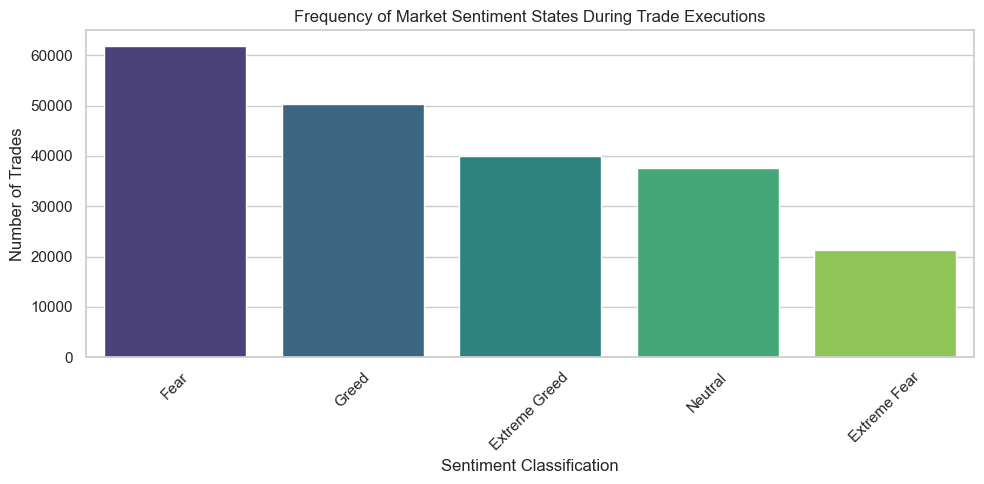

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_col = 'classification' 
sentiment_counts = df_merged[sentiment_col].value_counts()

print("Raw counts:\n", sentiment_counts)
total_missing = df_merged[sentiment_col].isnull().sum()
print(f"\nTotal trades missing sentiment data: {total_missing}")
print(f"Total rows in dataset: {len(df_merged)}")

if not sentiment_counts.empty:
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 5))
    sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette="viridis")
    plt.title("Frequency of Market Sentiment States During Trade Executions", fontsize=12)
    plt.xlabel("Sentiment Classification", fontsize=12)
    plt.ylabel("Number of Trades", fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("\nThe chart is empty because the merge failed to match any dates.")

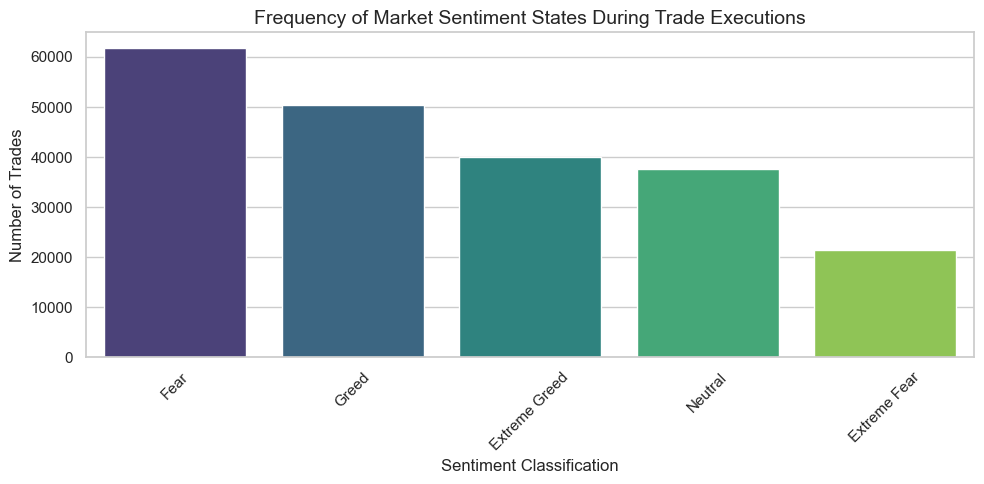

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))
sentiment_counts = df_merged['classification'].value_counts()
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette="viridis")

plt.title("Frequency of Market Sentiment States During Trade Executions", fontsize=14)
plt.xlabel("Sentiment Classification", fontsize=12)
plt.ylabel("Number of Trades", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Trading Behavior by Sentiment:

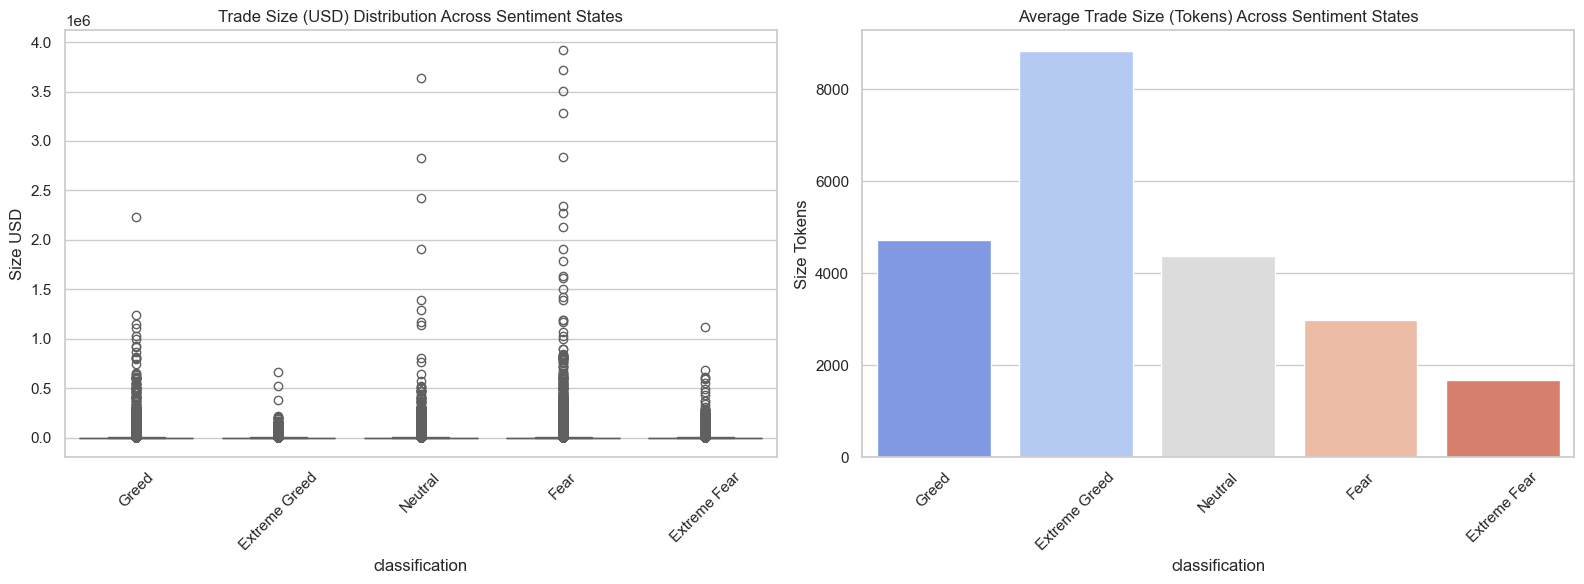

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Size USD by Sentiment 
sns.boxplot(data=df_merged, x='classification', y='Size USD', ax=axes[0], palette="coolwarm")
axes[0].set_title("Trade Size (USD) Distribution Across Sentiment States")
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Size Tokens by Sentiment 
sns.barplot(data=df_merged, x='classification', y='Size Tokens', ax=axes[1], palette="coolwarm", errorbar=None)
axes[1].set_title("Average Trade Size (Tokens) Across Sentiment States")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Profitability by Sentiment:

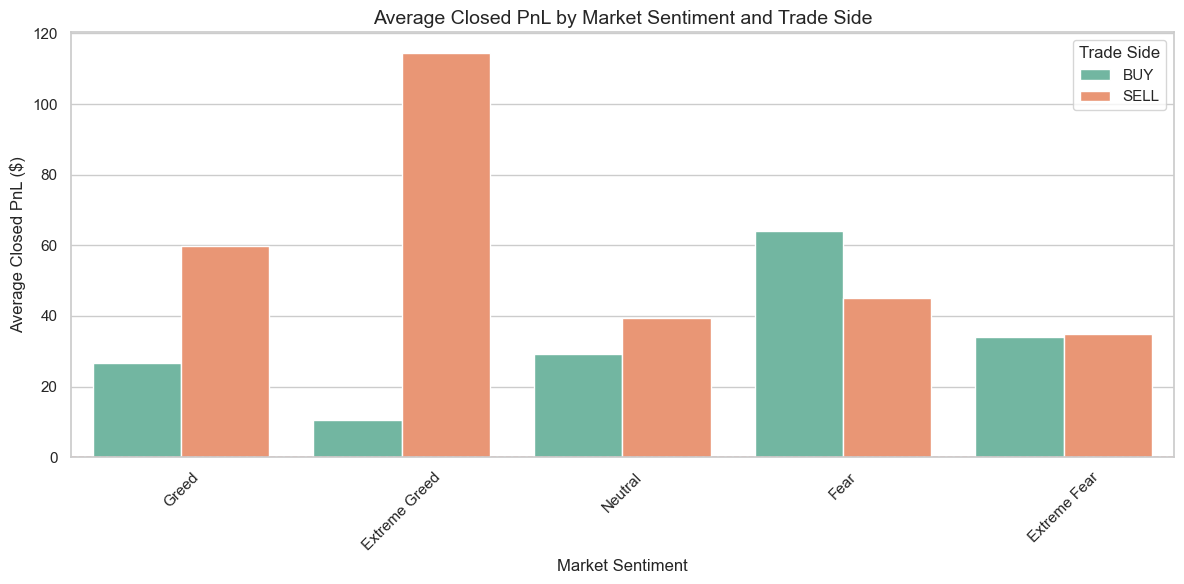

In [82]:
plt.figure(figsize=(12, 6))

sns.barplot(data=df_merged, x='classification', y='Closed PnL', hue='Side', palette="Set2", errorbar=None)

plt.title("Average Closed PnL by Market Sentiment and Trade Side", fontsize=14)
plt.xlabel("Market Sentiment", fontsize=12)
plt.ylabel("Average Closed PnL ($)", fontsize=12)
plt.axhline(0, color='red', linestyle='--', linewidth=1) # Adds a zero-profit line for reference
plt.xticks(rotation=45)
plt.legend(title="Trade Side")
plt.tight_layout()
plt.show()

Pattern Discovery & Insight Generation:

In [83]:
df_merged['is_profitable'] = df_merged['Closed PnL'] > 0

account_sentiment_stats = df_merged.groupby(['Account', 'classification']).agg(
    total_trades=('Closed PnL', 'count'),
    win_rate=('is_profitable', 'mean'),
    total_pnl=('Closed PnL', 'sum'),
    avg_trade_size=('Size USD', 'mean') # Replaced missing 'leverage'
).reset_index()

active_traders = account_sentiment_stats[account_sentiment_stats['total_trades'] > 10]

extreme_fear_winners = active_traders[active_traders['classification'] == 'Extreme Fear'].nlargest(5, 'total_pnl')

print("🟢 Top 5 Profitable Accounts During 'Extreme Fear' 🟢")
display(extreme_fear_winners)

🟢 Top 5 Profitable Accounts During 'Extreme Fear' 🟢


,Account,classification,total_trades,win_rate,total_pnl,avg_trade_size
142,0xbaaaf6571ab7d571043ff1e313a9609a10637864,Extreme Fear,4480,0.379464,261917.977792,4447.524038
80,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,Extreme Fear,221,0.420814,198900.561610,2613.952760
55,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,Extreme Fear,986,0.309331,166696.399486,10589.943783
0,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme Fear,100,0.370000,124769.221441,15071.008600
60,0x4f93fead39b70a1824f981a54d4e55b278e9f760,Extreme Fear,371,0.428571,74346.546606,25119.228652


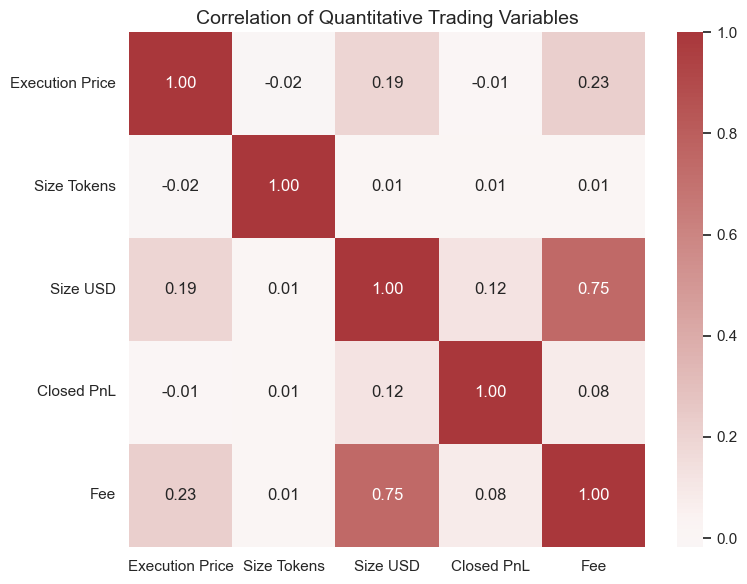

In [84]:
plt.figure(figsize=(8, 6))

# Select only numeric columns for correlation
numeric_cols = df_merged[['Execution Price', 'Size Tokens', 'Size USD', 'Closed PnL', 'Fee']]
corr_matrix = numeric_cols.corr()

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, cmap="vlag", center=0, fmt=".2f")
plt.title("Correlation of Quantitative Trading Variables", fontsize=14)
plt.tight_layout()
plt.show()